Realizado por:
* Diogo Vasco 2023226969 
* Rodrigo Gonçalves

In [1]:
import imblearn
import pandas as pd
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.tree import DecisionTreeRegressor
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt 
import numpy as np 
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier  
from sklearn.model_selection import cross_val_score  
from sklearn.metrics import precision_score, recall_score, f1_score 
from sklearn.preprocessing import MinMaxScaler 


sns.set_theme()

In [2]:
stressL='sleepStress.csv'
df= pd.read_csv(stressL)

## Exploratory Data Analysis

Before cleaning, we inspect the raw dataset to understand its size, structure, missing values, and the main variable distributions.

In [ ]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False))
print("\nDuplicate rows:", df.duplicated().sum())
print("\nNumerical summary:")
display(df.describe().T)
print("\nCategorical summary:")
display(df.describe(include='object').T)
display(df.head())

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Key Feature Distributions', fontsize=16)

sns.countplot(data=df, x='gender', order=df['gender'].value_counts().index, ax=axes[0, 0])
axes[0, 0].set_title('Gender')
axes[0, 0].set_xlabel('')

sns.countplot(data=df, x='occupation', order=df['occupation'].value_counts().index, ax=axes[0, 1])
axes[0, 1].set_title('Occupation')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].set_xlabel('')

sns.histplot(df['stress_level'], kde=True, ax=axes[1, 0], color='tomato')
axes[1, 0].set_title('Stress Level Distribution')

sns.histplot(df['sleep_duration_hours'], kde=True, ax=axes[1, 1], color='teal')
axes[1, 1].set_title('Sleep Duration Distribution')

plt.tight_layout()
plt.show()

In [ ]:
numeric_df = df.select_dtypes(include='number')
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Matrix for Numeric Features')
plt.show()

sem valores em falta, sem valores duplicados

In [7]:
print(df.isnull().sum())
df.duplicated().sum()

user_id                             0
age                                 0
gender                              0
occupation                          0
daily_screen_time_hours             0
phone_usage_before_sleep_minutes    0
sleep_duration_hours                0
sleep_quality_score                 0
stress_level                        0
caffeine_intake_cups                0
physical_activity_minutes           0
notifications_received_per_day      0
mental_fatigue_score                0
dtype: int64


np.int64(0)

In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder() 
corr = pd.DataFrame()
for col in df.columns: 
        corr[col] = le.fit_transform(df[col])

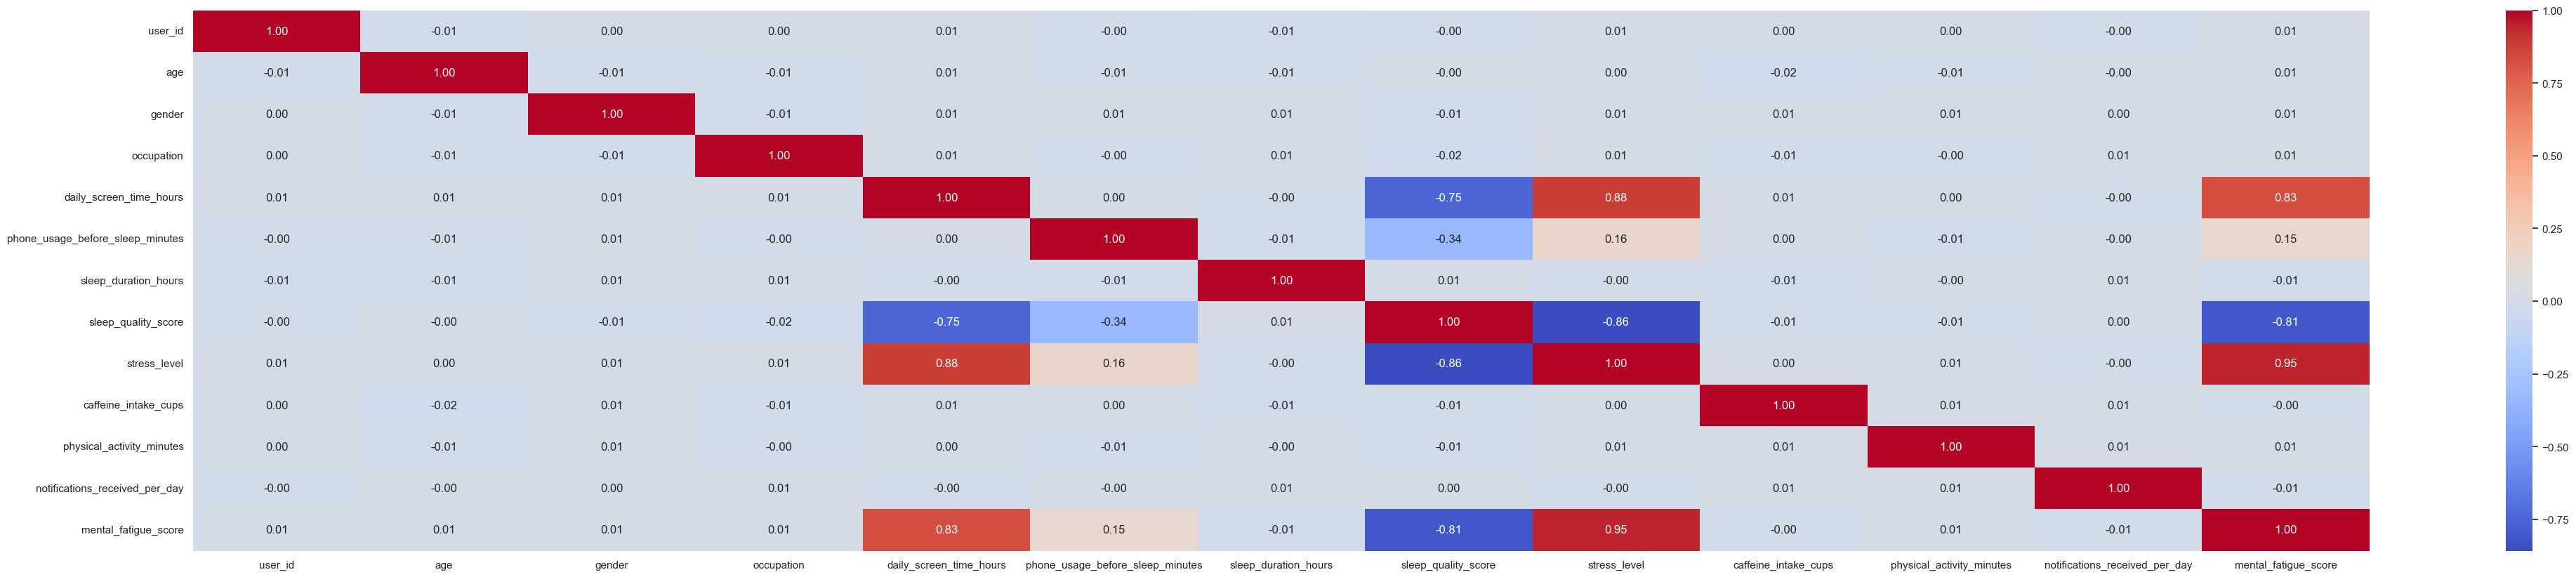

In [6]:
plt.figure(figsize=(50, 10))
correlation_matrix = corr.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()